---
## **Curso**: Pós-graduação em Ciência de Dados e Inteligência Artificial
## **Unidade Curricular**: Machine Learning
## **Professor**: Matheus Vanzan
## **Data**: 30/09/2025 (Aula Síncrona 7)
---

# **📌 Clusterização K-Means**

O **K-means** é um algoritmo de aprendizado de máquina **não supervisionado** usado para **agrupamento** de dados. Ele tem como objetivo dividir um conjunto de dados em **k grupos** distintos, onde cada grupo contém pontos semelhantes entre si, de acordo com uma métrica de distância.

O algoritmo busca minimizar a **variância intra-cluster**, ou seja, a soma das distâncias dos pontos ao seu respectivo centroide. Ele funciona iterativamente até que os centroides se estabilizem ou um critério de parada seja atingido.

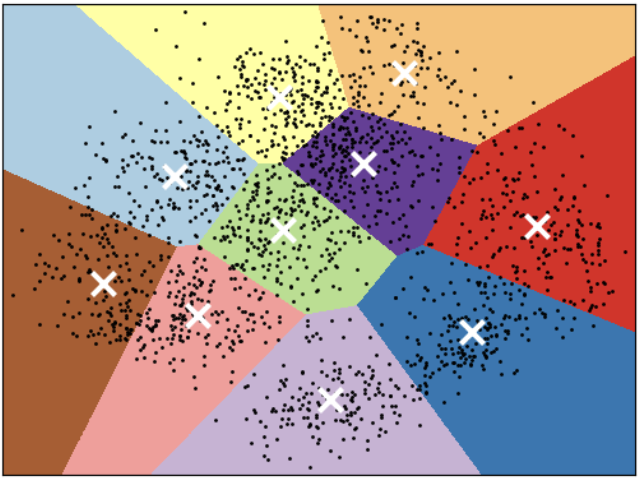

**Funcionamento do Algoritmo**

O K-means segue os seguintes passos:

1. **Escolher o número de clusters (k)**: O número de grupos deve ser definido previamente.
2. **Inicializar os centroides**: Selecionar aleatoriamente k pontos do conjunto de dados como centroides iniciais.
3. **Atribuir cada ponto ao centroide mais próximo**: Cada ponto do conjunto de dados é associado ao cluster cujo centroide está mais próximo, segundo a **distância Euclidiana**.
4. **Atualizar os centroides**: Para cada cluster, o novo centroide é calculado como a **média** das coordenadas dos pontos atribuídos a ele.
5. **Repetir os passos 3 e 4** até a convergência: O processo se repete até que os centroides não mudem mais significativamente ou atinja um número máximo de iterações.

![K-means](https://miro.medium.com/v2/resize:fit:1280/format:webp/1*om8sQXtJkzHG0G8ZlTuW9g.gif)

**Distância Euclidiana**

A atribuição de clusters é feita com base na **distância Euclidiana**, que mede a proximidade entre um ponto $ x_i $ e um centroide $ c_j $:

$$
d(x_i, c_j) = \sqrt{(x_{i1} - c_{j1})^2 + (x_{i2} - c_{j2})^2 + ... + (x_{in} - c_{jn})^2}
$$

onde:
- $ x_{i} $ é um ponto do conjunto de dados,
- $ c_{j} $ é um centroide,
- $ n $ é o número de dimensões dos dados.

<img src="https://media.datacamp.com/cms/google/ad_4nxeos8u3kqhkabqfa1v42eim0w8jrbrbygh937rjvgebjaymxoegx0eqhdx4jgtp9oacbgxwbe8qxa2fhi1jrodha6lszwgcucuea3g4osutnt-gug0g2rq3iok6otftdze1eazpqu18ifuybegox6f5ab4.png" width="500">

**Atualização dos Centroides**

O centroide de cada cluster é atualizado como a média dos pontos atribuídos a ele:

$$
c_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i
$$

onde:
- $ C_j $ é o conjunto de pontos pertencentes ao cluster $ j $.
- $ |C_j| $ representa a **quantidade de pontos** no cluster $ j $.
- A soma $ \sum_{x_i \in C_j} x_i $ percorre todos os pontos $ x_i $ que pertencem ao cluster $ C_j $.

O resultado final é a **média aritmética** dos pontos, que atualiza a posição do centroide.

<img src="https://www.oreilly.com/api/v2/epubs/9781838821739/files/assets/ba527ec3-e985-40e5-84a5-e77943091df3.png" width="500">

**Critério de Convergência**

O algoritmo para quando:
1. Os centroides não mudam entre duas iterações consecutivas.
2. O número máximo de iterações é atingido.

## **💡 Exemplo didático**

### **1. Importação das Bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, SpectralEmbedding

from sklearn.datasets import make_moons, make_circles
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, homogeneity_score, completeness_score, v_measure_score

### **2. Geração dos Dados**

Aqui:
- Geramos dois **conjuntos de pontos** que seguem uma distribuição normal.
- Cada ponto tem duas coordenadas (2D) para facilitar a visualização.
- `np.random.randn(50, 2)`: Gera 50 pontos seguindo uma **distribuição normal padrão**.
- `+ np.array([2,2])`: Move os pontos para a posição desejada (translação no espaço).
- `np.vstack([data1, data2])`: Junta os dois clusters.

In [ ]:
np.random.seed(42)

cluster1 = np.random.randn(50, 2) + np.array([2, 2])
cluster2 = np.random.randn(50, 2) + np.array([-2, -2])

data = np.vstack([cluster1, cluster2])

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data[:, 0], data[:, 1], color='blue')
plt.title("Conjunto de Dados Sintético")

plt.show()

### **3. Criação e Treinamento do Modelo**


In [ ]:
k = 2 # Número de clusters

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(data)

### **4. Obtenção dos Rótulos e Centroides**

- `labels = kmeans.labels_`: Para cada ponto, retorna o índice do cluster ao qual ele pertence.
- `centroids = kmeans.cluster_centers_`: Contém as coordenadas dos centroides finais após a convergência do algoritmo.
- Exibimos os valores dos centroides para análise.

In [ ]:
labels = kmeans.predict(data)
labels

In [ ]:
labels = kmeans.labels_
labels

In [ ]:
centroids = kmeans.cluster_centers_
centroids

### **5. Visualização final dos clusters**

- **Cores diferentes** representam os clusters finais.
- Os **centroides finais** são marcados como **"X" vermelho**.
- Podemos visualizar como os pontos foram agrupados.

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='bwr', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='yellow', edgecolors="k", s=150, marker="*", label='Centroides')
plt.legend()
plt.title("Clusters encontrados pelo K-means")

plt.show()

### **6. Métricas de avaliação**


- **Inércia (SSE / WCSS)**  
  Soma das distâncias quadráticas dos pontos ao centróide do seu cluster.  
  → Quanto menor, mais compactos os clusters. Sempre diminui quando K aumenta.

- **Silhouette**  
  Mede coesão (distância dentro do cluster) e separação (distância até o cluster vizinho mais próximo).  
  → Varia de -1 a 1. Valores próximos de **1** indicam boa formação de clusters.

- **Calinski–Harabasz (CH Index)**  
  Razão entre a variância entre clusters e a variância dentro dos clusters.  
  → Quanto maior, melhor a separação entre grupos.

- **Davies–Bouldin (DB Index)**  
  Média da semelhança entre cada cluster e o mais parecido com ele.  
  → Quanto menor, melhor (clusters mais distintos).

In [ ]:
inertia = kmeans.inertia_
inertia

In [ ]:
silhouette = silhouette_score(data, labels)
silhouette

In [ ]:
ch_index = calinski_harabasz_score(data, labels)
ch_index

In [ ]:
db_index = davies_bouldin_score(data, labels)
db_index

# **📊 Dataset Mall Customers**

Você foi contratado como **Cientista de Dados** por uma grande rede de shopping centers que deseja entender melhor o perfil de seus clientes para otimizar suas estratégias de marketing. O objetivo é agrupar os clientes de acordo com seu **rendimento anual** e seu **índice de gastos**, identificando padrões de comportamento de consumo.

Para isso, você utilizará o **algoritmo K-Means**, que permitirá segmentar os clientes em diferentes grupos com características semelhantes.

**Implementação utilizando `scikit-learn`**  

   - Utilize a biblioteca `scikit-learn` para aplicar o K-Means e compare os resultados com a implementação manual.
   - A saída deve incluir os clusters finais e um gráfico de dispersão ilustrando a segmentação.

Por fim, analise se há diferenças significativas nos agrupamentos gerados.



---



**Dataset**: https://raw.githubusercontent.com/matheusvanzan/Machine-Learning-Examples/refs/heads/master/datasets/Mall_Customers.csv


O dataset **"Mall Customers"** contém informações sobre clientes de um shopping center, utilizadas para análise de segmentação de clientes com base em características demográficas e comportamentais.

> **Descrição das variáveis:**
- **CustomerID**: Identificação única do cliente.
- **Gender**: Gênero do cliente (Masculino/Feminino).
- **Age**: Idade do cliente (em anos).
- **Annual_Income_(k$)**: Renda anual do cliente (em milhares de dólares).
- **Spending_Score**: Índice de gastos do cliente (escala de 1 a 100), indicando o nível de consumo com base em hábitos de compra.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## **1. Análise dos Dados**

In [ ]:
mall_customers_url = 'https://raw.githubusercontent.com/matheusvanzan/Machine-Learning-Examples/refs/heads/master/datasets/Mall_Customers.csv'

df = pd.read_csv(mall_customers_url)

In [ ]:
df.head()

In [ ]:
df = df.dropna().copy()

In [ ]:
df.shape

## **2. Treinamento com 2 features**

In [ ]:
df_2d = df[['Annual_Income_(k$)', 'Spending_Score']]
df_2d.head()

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(df_2d['Annual_Income_(k$)'], df_2d['Spending_Score'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Annual Income vs. Spending Score')
plt.grid(True)

plt.show()

> **🎯 Momento de Praticar**

In [ ]:
categorical = df_2d.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = df_2d.select_dtypes(include='number').columns.tolist()
numerical

⚠️ Como o K-Means usa distâncias Euclidianas, features em escalas diferentes podem interferir no treinamento. Teriam "pesos" diferentes. Por isso usamos um Scaler.

In [ ]:
pre_kmeans = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical)
    ]
)

In [ ]:
k = 5 # Número de clusters

pipe_kmeans = Pipeline([
    ('pre', pre_kmeans),
    ('kmeans', KMeans(n_clusters=k, random_state=42))
])
pipe_kmeans.fit(df_2d)

## **3. Verificação dos Labels e Centroides**

In [ ]:
labels_initial = pipe_kmeans.named_steps['kmeans'].labels_
labels_initial

In [ ]:
centroids_scaled = pipe_kmeans.named_steps['kmeans'].cluster_centers_
centroids_scaled

In [ ]:
scaler = pipe_kmeans.named_steps['pre'].named_transformers_['num']
centroids = scaler.inverse_transform(centroids_scaled)
centroids

In [ ]:
labels = pipe_kmeans.predict(df_2d)
labels

## **4. Visualização final dos clusters**

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_2d['Annual_Income_(k$)'], df_2d['Spending_Score'], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100, label='Centroides')
plt.legend()
plt.title("Clusters encontrados pelo K-means")

plt.show()

### Métricas de avaliação



- **Inércia (SSE / WCSS)**  
  Soma das distâncias quadráticas dos pontos ao centróide do seu cluster.  
  → Quanto menor, mais compactos os clusters. Sempre diminui quando K aumenta.

- **Silhouette**  
  Mede coesão (distância dentro do cluster) e separação (distância até o cluster vizinho mais próximo).  
  → Varia de -1 a 1. Valores próximos de **1** indicam boa formação de clusters.

- **Calinski–Harabasz (CH Index)**  
  Razão entre a variância entre clusters e a variância dentro dos clusters.  
  → Quanto maior, melhor a separação entre grupos.

- **Davies–Bouldin (DB Index)**  
  Média da semelhança entre cada cluster e o mais parecido com ele.  
  → Quanto menor, melhor (clusters mais distintos).

In [ ]:
inertia = pipe_kmeans.named_steps['kmeans'].inertia_
inertia

In [ ]:
silhouette = silhouette_score(df_2d, labels)
silhouette

In [ ]:
ch_index = calinski_harabasz_score(df_2d, labels)
ch_index

In [ ]:
db_index = davies_bouldin_score(df_2d, labels)
db_index

## **5. Escolha do valor de K**

**Métodos Elbow e Silhouette**

A escolha do número ideal de clusters é uma etapa crucial na aplicação do K-Means. Dois métodos populares para essa decisão são o **Método do Cotovelo (Elbow)** e a **Análise de Silhouette**.

- **Método do Elbow**: Consiste em executar o K-Means para diferentes valores de *k* e plotar a **inércia** (soma das distâncias quadradas aos centroides) em função de *k*. À medida que *k* aumenta, a inércia diminui. O ponto onde a taxa de diminuição se estabiliza, formando um “cotovelo” na curva, é considerado o número ideal de clusters.

- **Análise de Silhouette**: Avalia o quão bem cada ponto está agrupado em seu cluster. O **Silhouette Score** varia entre -1 e 1, onde valores mais altos indicam melhor separação entre os clusters. Calcula-se o score médio para diferentes *k*, e o valor que maximiza essa média costuma ser uma boa escolha para o número de clusters.

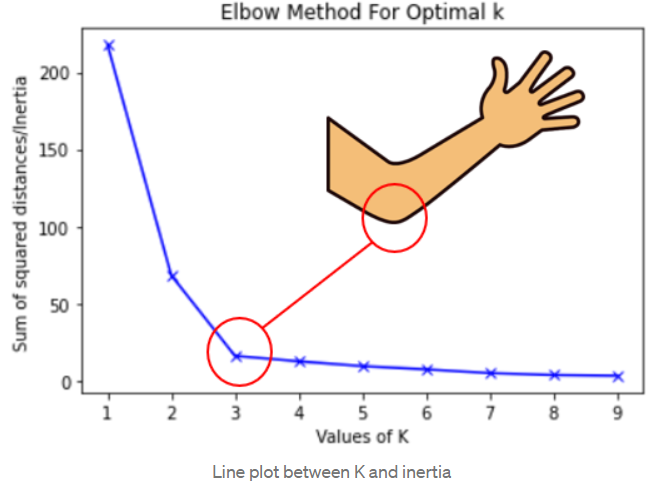

In [ ]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    pipe = Pipeline([
        ('pre', pre_kmeans),
        ('kmeans', KMeans(n_clusters=k, n_init=10, random_state=42))
    ])
    pipe.fit(df_2d)

    inertias.append(pipe.named_steps['kmeans'].inertia_)
    silhouettes.append(silhouette_score(df_2d, pipe.named_steps['kmeans'].labels_))

In [ ]:
print(inertias)

In [ ]:
drops = [np.nan] + [1 - inertias[i] / inertias[i-1] for i in range(1, len(inertias))]
print(drops)

In [ ]:
# Heurística: pegue o maior k ANTES da primeira queda ficar < 10% (plateau)
k_elbow = 3 # valor default
mask = np.asarray(drops) < 0.1
if mask.any():
    i = max(int(np.argmax(mask)) - 1, 0)  # maior k antes da 1ª queda < 10%
    k_elbow = k_range[i]

print(f"Método do cotovelo (heurística 10%): k = {k_elbow}")

In [ ]:
print(silhouettes)

In [ ]:
# Queremos o valor máximo
k_sil = k_range[np.argmax(silhouettes)]

print(f"Método de silhouettes (valor máximo): k = {k_sil}")

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(list(k_range), inertias, marker='o')
plt.xticks(list(k_range))

plt.title('Método do Cotovelo (Inertia/SSE)')
plt.xlabel('k')
plt.ylabel('Inertia (SSE)')
plt.grid(True, alpha=0.3)

# linha vertical no k sugerido
plt.axvline(k_elbow, linestyle='--', alpha=0.8, color='tab:orange', label=f'k_elbow = {k_elbow}')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,4))

plt.plot(list(k_range), silhouettes, marker='o')
plt.xticks(list(k_range))

plt.title('Coeficiente de Silhouette')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.grid(True, alpha=0.3)

# linha vertical no k sugerido
plt.axvline(k_sil, linestyle=':', alpha=0.8, color='tab:green', label=f'k_sil = {k_sil}')
plt.legend()
plt.tight_layout()
plt.show()

Normalmente, calculamos os dois valores e utilizamos o menor.

In [ ]:
k = min(k_elbow, k_sil)
k

## **6. Treinamento com todas as features**

In [ ]:
df = df.drop(columns=['CustomerID']).copy()

In [ ]:
df.head()

> **🎯 Momento de Praticar**

In [ ]:
categorical = df.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = df.select_dtypes(include='number').columns.tolist()
numerical

In [ ]:
cat_pre = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False)),
    ('scaler', StandardScaler())
])

In [ ]:
pre_kmeans = ColumnTransformer(
    transformers=[
        ('cat', cat_pre, categorical),
        ('num', StandardScaler(), numerical)
    ]
)

In [ ]:
k = 3 # Número de clusters

pipe_kmeans = Pipeline([
    ('pre', pre_kmeans),
    ('kmeans', KMeans(n_clusters=k, random_state=42))
])
pipe_kmeans.fit(df)

In [ ]:
columns = pipe_kmeans.named_steps['pre'].get_feature_names_out()
columns

In [ ]:
data_transformed = pipe_kmeans.named_steps['pre'].transform(df)
df_transformed = pd.DataFrame(data=data_transformed, columns=columns)
df_transformed.head()

In [ ]:
centroids_scaled = pipe_kmeans.named_steps['kmeans'].cluster_centers_
centroids_scaled

In [ ]:
labels = pipe_kmeans.predict(df)
labels

> **Visualização final dos clusters**

In [ ]:
columns

In [ ]:
col1 = 'num__Annual_Income_(k$)'
col2 = 'num__Spending_Score'

plt.figure(figsize=(8,6))
plt.scatter(df_transformed[col1], df_transformed[col2], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], c='red', marker='X', s=100, label='Centroides')
plt.legend()
plt.title("Clusters encontrados pelo K-means")

plt.show()

# **📌 Redução de Dimensionalidade**

As métricas internas ajudam a avaliar a qualidade dos clusters, mas é difícil definir um valor “ideal” só olhando para elas. Muitas vezes, o jeito mais intuitivo de verificar se a clusterização fez sentido é **visualizar os grupos**.  

O problema é que nem sempre dá para visualizar diretamente, porque os dados podem estar em muitas dimensões. Para isso, usamos técnicas de **redução de dimensionalidade**, como o **PCA** ou **SNE**, que projetam os dados em 2D ou 3D. Assim conseguimos plotar os pontos coloridos pelos rótulos do K-Means e ter uma ideia visual de como os clusters se formaram.


### **➡️ PCA**

O **PCA (Principal Component Analysis)** é uma técnica de **redução de dimensionalidade**.  
Seu objetivo é transformar os dados originais em um novo espaço de variáveis, chamadas de **componentes principais**, que explicam a maior parte da variância dos dados.  

Características principais:
- É um **método linear**: encontra combinações lineares das variáveis originais.  
- Os componentes principais são **ortogonais** (não correlacionados entre si).  
- O **primeiro componente** captura a maior variação possível; o segundo, a segunda maior, e assim por diante.  
- Permite reduzir de muitas dimensões para apenas 2 ou 3, mantendo a maior parte da informação.  

Na prática, o PCA é muito usado para **visualização de clusters** (como os do K-Means) e para **pré-processamento** em modelos de Machine Learning.


In [ ]:
cat_pre = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False)),
    ('scaler', StandardScaler())
])

In [ ]:
pre_pca = ColumnTransformer(
    transformers=[
        ('cat', cat_pre, categorical),
        ('num', StandardScaler(), numerical)
    ]
)

In [ ]:
pipe_pca = Pipeline(steps=[
    ('pre', pre_pca),
    ('pca', PCA(n_components=2, random_state=42))
])
pipe_pca.fit(df)

In [ ]:
data_pca = pipe_pca.transform(df)
df_pca = pd.DataFrame(data=data_pca, columns=pipe_pca.get_feature_names_out())
df_pca.head()

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_pca['pca0'], df_pca['pca1'], alpha=0.7)
plt.xlabel('pca0')
plt.ylabel('pca1')
plt.title('PCA: redução para 2 features')
plt.tight_layout()
plt.show()

## ➡️ K-Means e busca pelo valor de K

In [ ]:
def find_k():

    k_range = range(3, 21)
    inertias = []
    silhouettes = []

    for k in k_range:
        pipe = Pipeline([
            ('pre', pre_pca),
            ('pca', PCA(n_components=2, random_state=42)),
            ('kmeans', KMeans(n_clusters=k, random_state=42))
        ])
        df_pca_kmeans = pipe.fit_transform(df)

        inertias.append(pipe.named_steps['kmeans'].inertia_)
        silhouettes.append(silhouette_score(df_pca_kmeans, pipe.named_steps['kmeans'].labels_))

    drops = [np.nan] + [1 - inertias[i] / inertias[i-1] for i in range(1, len(inertias))]

    # Heurística: pegue o maior k ANTES da primeira queda ficar < 10% (plateau)
    k_elbow = 3 # valor default
    mask = np.asarray(drops) < 0.1
    if mask.any():
        i = max(int(np.argmax(mask)) - 1, 0)  # maior k antes da 1ª queda < 10%
        k_elbow = k_range[i]

    print(f"Método do cotovelo (heurística 10%): k = {k_elbow}")

    # Queremos o valor máximo
    k_sil = k_range[np.argmax(silhouettes)]

    print(f"Método de silhouettes (valor máximo): k = {k_sil}")

    return min(k_elbow, k_sil)

In [ ]:
k = find_k()
k

> **🎯 Momento de Praticar**

In [ ]:
pipe_pca_kmeans = Pipeline(steps=[
    ('pre', pre_pca),
    ('pca', PCA(n_components=2, random_state=42)),
    ('kmeans', KMeans(n_clusters=k, random_state=42))
])
pipe_pca_kmeans.fit(df)

In [ ]:
X_transformed = pipe_pca_kmeans.named_steps['pre'].transform(df)
X_pca = pipe_pca_kmeans.named_steps['pca'].transform(df_transformed)

df_pca = pd.DataFrame(data=X_pca, columns=['pca0', 'pca1'])
df_pca.head()

In [ ]:
labels = pipe_pca_kmeans.predict(df)
labels

In [ ]:
centroids_scaled = pipe_pca_kmeans.named_steps['kmeans'].cluster_centers_
centroids_scaled

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_pca['pca0'], df_pca['pca1'], cmap='viridis', c=labels, alpha=0.7)
plt.xlabel('pca0')
plt.ylabel('pca1')
plt.title('PCA (2 feat) + K-Means')
plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], c='red', marker='X', s=100, label='Centroides')
plt.legend()
plt.tight_layout()
plt.show()

## ➡️ t-SNE


O **t-SNE (t-distributed Stochastic Neighbor Embedding)** é um algoritmo de **aprendizado não supervisionado** da classe dos métodos de **redução de dimensionalidade**, com foco em **visualização de dados de alta dimensão**.  

Diferente de técnicas lineares como o **PCA**, o t-SNE é **não linear** e procura **preservar as relações locais** entre os dados.  
Ou seja, pontos que são próximos no espaço original permanecem próximos no espaço reduzido (2D ou 3D), facilitando a visualização de **agrupamentos e estruturas complexas**.  

> **Como funciona (resumidamente)**  
1. Calcula as **probabilidades de semelhança** entre pares de pontos no espaço original, baseadas na distância euclidiana e convertidas em **distribuições Gaussianas**.  
2. Procura uma representação em menor dimensão que preserve essas relações, agora usando uma **distribuição t de Student**, que ajuda a reduzir o *crowding problem* (quando muitos pontos diferentes se sobrepõem na redução de dimensão).  

> **Características principais**  
- Muito eficaz em **revelar clusters e subgrupos** ocultos.  
- Amplamente utilizado em áreas como **bioinformática, NLP e análise de imagens**.  
- **Computacionalmente intensivo** e com resultados que podem variar entre execuções.  
- Não preserva **escalas globais** ou **distâncias absolutas**, sendo mais indicado para **exploração visual**.  

> **Conclusão**  
O t-SNE não deve ser usado como ferramenta analítica formal, mas sim como uma poderosa forma de **exploração e visualização** de dados complexos, tornando “visível o invisível”.  




<img src="https://miro.medium.com/v2/resize:fit:1328/1*ul098l7okVnmoWA1Ns-nwQ.png" width="500">

> **🎯 Momento de Praticar**

In [ ]:
df.head()

> ⚠️ TSNE não implementa o método `transform()`, então deve ser sempre o último passo da `Pipeline`

In [ ]:
pipe_tsne = Pipeline([
    ('pre', pre_pca),
    ('tsne', TSNE(n_components=2, perplexity=30, random_state=42))
])

data_tsne = pipe_tsne.fit_transform(df)
type(data_tsne)

In [ ]:
df_tsne = pd.DataFrame(data_tsne, columns=['tsne0', 'tsne1'])
df_tsne.head()

In [ ]:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(df_tsne)

In [ ]:
labels = kmeans.labels_
labels

In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids_scaled

In [ ]:
pipe_tsne.get_feature_names_out()

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_tsne['tsne0'], df_tsne['tsne1'], cmap='viridis', c=labels, alpha=0.7)
plt.xlabel('tsne0')
plt.ylabel('tsne1')
plt.title('t-SNE (2 feat) + K-Means')
plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], c='red', marker='X', s=100, label='Centroides')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
inertia = kmeans.inertia_
inertia

In [ ]:
silhouette = silhouette_score(df_tsne, labels)
silhouette

In [ ]:
ch_index = calinski_harabasz_score(df_tsne, labels)
ch_index

In [ ]:
db_index = davies_bouldin_score(df_tsne, labels)
db_index

## ➡️ Comparação PCA vs. t-SNE (Mall Customers)

> **PCA**

- Método linear: combina as features originais em novas componentes ortogonais.

- Mantém a estrutura global dos dados, mas pode não separar bem clusters não lineares.

- No gráfico, os clusters aparecem mais sobrepostos e próximos, com centróides que não se destacam tanto.

- Bom para redução de dimensionalidade interpretável e como pré-processamento antes de algoritmos.

> **t-SNE**

- Método não linear, focado em preservar relações locais (pontos vizinhos continuam vizinhos).

- Consegue evidenciar melhor a separação entre grupos quando há padrões complexos.

- No gráfico, os clusters aparecem mais definidos e distantes entre si, facilitando a interpretação visual.

- Porém: é mais lento e não permite `.transform()` em novos dados.

# **📌 Spectral Clustering**

O **Spectral Clustering** é um algoritmo de aprendizado de máquina **não supervisionado** usado para **agrupamento** de dados. Diferente de métodos como o K-means, que se baseiam em suposições de forma esférica dos clusters, o Spectral Clustering é mais **flexível** e eficaz para identificar **estruturas complexas** e **não lineares** nos dados, como agrupamentos com formas arbitrárias.

Esse algoritmo utiliza conceitos da **Teoria dos Grafos** e da **Álgebra Linear**, baseando-se na estrutura do grafo formado pelas amostras, onde as conexões representam similaridades entre os pontos.


**Funcionamento do Algoritmo**

O Spectral Clustering segue os seguintes passos:

1. **Construir a matriz de afinidade**: Criar uma matriz que representa o grau de similaridade entre cada par de pontos. Pode-se usar, por exemplo, a **similaridade Gaussiana (RBF)** ou k-vizinhos mais próximos.
2. **Construir o grafo e calcular a Laplaciana**: Com base na matriz de afinidade, constrói-se um grafo e calcula-se a **matriz Laplaciana** (normalizada ou não), que captura a estrutura do grafo.
3. **Calcular os autovetores da Laplaciana**: Extraem-se os **k menores autovetores** correspondentes aos menores autovalores da matriz Laplaciana. Esses vetores formam uma nova representação dos dados em um espaço de menor dimensão.
4. **Aplicar K-means nesse novo espaço**: Utiliza-se o **K-means** sobre os dados transformados (autovetores) para realizar o agrupamento final.


**Vantagens do Spectral Clustering**

- **Capacidade de detectar clusters com formas complexas** ou não convexas, que métodos como o K-means não conseguem identificar bem.
- **Versatilidade** na definição de similaridade, permitindo ajustar o algoritmo ao tipo de dado e estrutura do problema.
- **Base teórica sólida**, com fundamentos em teoria espectral e grafos.

<img src="https://gjkoplik.github.io/spectral_clustering/top_figure.png" width="500">

## Exemplo didático

In [ ]:
X, y_true = make_moons(n_samples=800, noise=0.08, random_state=42)
# X, y_true = make_circles(factor=0.6, noise=0.05, random_state=42)

In [ ]:
plt.scatter(X[:,0], X[:,1], s=8); plt.title('Dados make moons')

In [ ]:
# KMeans direto no espaço original
labels_km = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X)

In [ ]:
# SpectralClustering
labels_sc = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans',
    random_state=42
).fit_predict(X)

In [ ]:
# Embedding espectral para plot e KMeans depois
Z = SpectralEmbedding(n_components=2, n_neighbors=10, random_state=42).fit_transform(X)
labels_se = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Z)

In [ ]:
# Visualização rápida
plt.figure(figsize=(9,3))
plt.subplot(1,3,1); plt.scatter(X[:,0], X[:,1], c=labels_km, s=8); plt.title('KMeans no original')
plt.subplot(1,3,2); plt.scatter(X[:,0], X[:,1], c=labels_sc, s=8); plt.title('SpectralClustering')
plt.subplot(1,3,3); plt.scatter(Z[:,0], Z[:,1], c=labels_se, s=8); plt.title('SpectralEmbedding + KMeans')
plt.tight_layout(); plt.show()


## Dataset Mall Customers

In [ ]:
pipe_spec = Pipeline([
    ('pre', pre_pca),
    ('spec', SpectralClustering(n_clusters=5, assign_labels='cluster_qr', affinity='nearest_neighbors', random_state=42))
])

data_spec = pipe_tsne.fit_transform(df)
type(data_spec)

In [ ]:
df_spec = pd.DataFrame(data_spec, columns=['spec0', 'spec1'])
df_spec.head()

In [ ]:
labels = pipe_spec.fit_predict(df)
labels

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_spec['spec0'], df_spec['spec1'], cmap='viridis', c=labels, alpha=0.7)
plt.xlabel('spec0')
plt.ylabel('spec1')
plt.title('Spectral Clustering (2 feat)')
plt.legend()
plt.tight_layout()
plt.show()

# **💻 Exercício**


**PCA + K-Means no Dataset Breast Cancer**  

Agora vamos aplicar o **PCA** e o **K-Means** ao dataset **Breast Cancer** disponível no `scikit-learn`.  
O objetivo é:  

1. **Reduzir a dimensionalidade** dos dados para **2 componentes principais** usando PCA.  
2. **Aplicar o algoritmo de K-Means** para realizar a clusterização nos dados transformados.
3. **Visualização** dos dados transformados.

Desafio: Compare a aplicação de um mesmo modelo como dataset completo e com o dataset reduzido em menos variáveis.

In [ ]:
from sklearn.datasets import load_breast_cancer

In [ ]:
data = load_breast_cancer()

In [ ]:
data.feature_names

In [ ]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)

In [ ]:
df['target'] = data.target_names[data.target]

In [ ]:
df.head()

> **🎯 Momento de Praticar**

In [ ]:
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

In [ ]:
categorical = X.select_dtypes(include='object').columns.tolist()
categorical

In [ ]:
numerical = X.select_dtypes(include='number').columns.tolist()
numerical

In [ ]:
pre_kmeans = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical)
    ]
)

In [ ]:
pipe_pca_kmeans = Pipeline(steps=[
    ('pre', pre_kmeans),
    ('pca', PCA(n_components=2, random_state=42)),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])
pipe_pca_kmeans.fit(X)

In [ ]:
X_transformed = pipe_pca_kmeans.named_steps['pre'].transform(X)
X_pca = pipe_pca_kmeans.named_steps['pca'].transform(X_transformed)

df_pca = pd.DataFrame(data=X_pca, columns=['pca0', 'pca1'])
df_pca.head()

In [ ]:
labels = pipe_pca_kmeans.predict(df)
labels

In [ ]:
centroids_scaled = pipe_pca_kmeans.named_steps['kmeans'].cluster_centers_
centroids_scaled

In [ ]:
# pd.Categorical(y).codes

**Comparativo com as classes reais**

- plote o gráfico de dispersão utilizando as classes do K-Means e utilizando as classes reais

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

y_plot = pd.Categorical(y).codes

# Esquerda: clusters do K-Means
sc0 = axes[0].scatter(df_pca['pca0'], df_pca['pca1'], c=labels, cmap='viridis', alpha=0.7, s=20)
axes[0].scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], c='red', marker='X', s=100, label='Centróides')
axes[0].set_xlabel('pca0')
axes[0].set_ylabel('pca1')
axes[0].set_title('PCA (2 feat) + K-Means')
axes[0].legend()

# Direita: classes reais
sc1 = axes[1].scatter(df_pca['pca0'], df_pca['pca1'], c=y_plot, cmap='viridis', alpha=0.7, s=20)
axes[1].set_xlabel('pca0')
axes[1].set_ylabel('pca1')
axes[1].set_title('PCA (2 feat) + classes reais (y)')

plt.tight_layout()
plt.show()

**Homogeneity, Completeness e V-Measure**

Essas três métricas são amplamente utilizadas para avaliar a qualidade de algoritmos de clusterização quando há **rótulos verdadeiros** disponíveis para comparação.

- **Homogeneity** (Homogeneidade) indica se cada cluster gerado contém apenas amostras de uma única classe. Um valor alto significa que os clusters são "puros", ou seja, não misturam categorias diferentes.

- **Completeness** (Completude) avalia se todos os elementos de uma mesma classe foram atribuídos ao mesmo cluster. Ou seja, mede o quanto uma classe foi completamente capturada dentro de um único grupo.

- **V-Measure** é a média harmônica entre homogeneity e completeness, fornecendo uma visão equilibrada entre pureza dos clusters e integridade da representação das classes.

Todos esses valores variam entre 0 e 1, sendo que **quanto mais próximo de 1, melhor** é o desempenho da clusterização em relação aos rótulos reais.

In [ ]:
silhouette = silhouette_score(X_transformed, labels)
homogeneity = homogeneity_score(y, labels)
completeness = completeness_score(y, labels)
v_measure = v_measure_score(y, labels)

In [ ]:
print(f"Silhouette: {silhouette:.4}")
print(f"Homogeneity: {homogeneity:.4}")
print(f"Completeness: {completeness:.4}")
print(f"V-Measure: {v_measure:.4}")